### __Agent__
__Review__\
We built a router.

Our chat model will decide to make a tool call or not based upon the user input\
We use a conditional edge to route to a node that will call our tool or simply end.

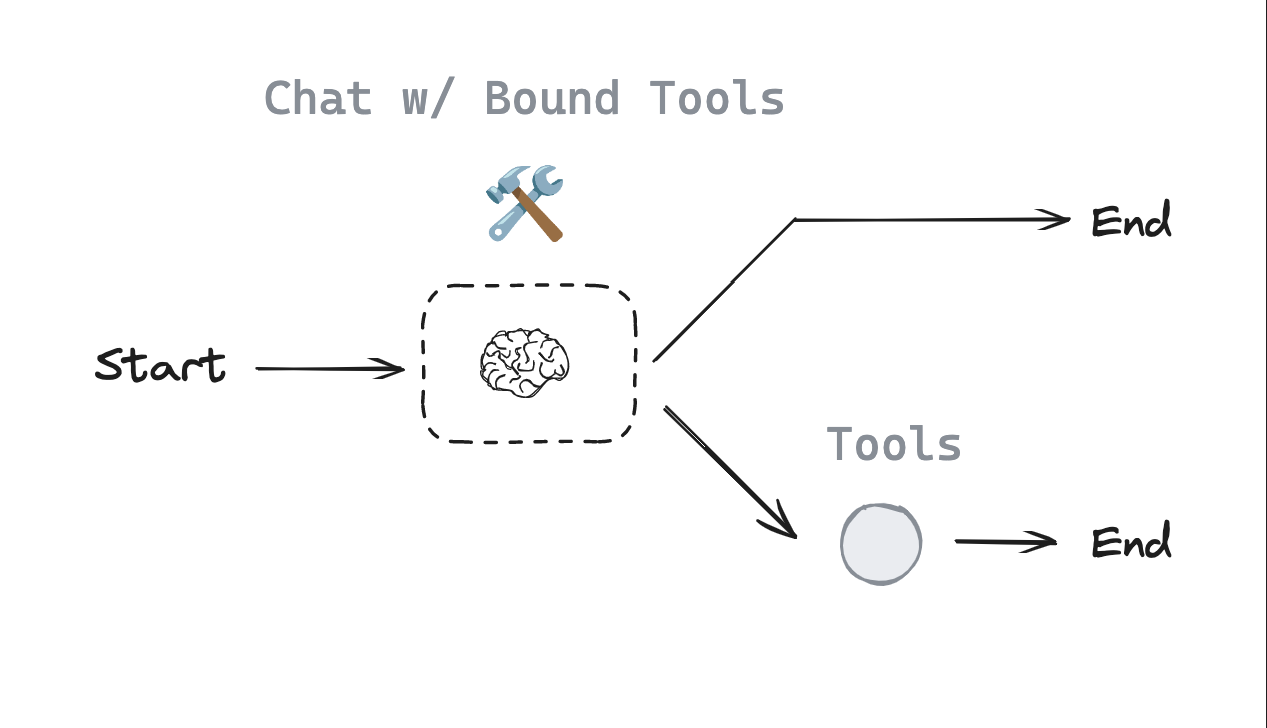

__Objective__
Now, we can extend this into a generic agent architecture.

In the above router, we invoked the model and, if it __chose to call a tool__, we returned a `ToolMessage` to the user.

But, what if we simply pass that `ToolMessage` back to the `model`?

We can let it either (1) _call another tool_ or (2) _respond directly_.

This is the intuition behind __`ReAct`__, a general agent architecture.

* `act` - let the model call specific tools
* `observe` - pass the tool output back to the model
* `reason` - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)\
This general purpose architecture can be applied to many types of tools.



In [7]:
import os
from dotenv import load_dotenv
load_dotenv()
NV_API_KEY = os.getenv("NV_API_KEY")
NV_API_URL = os.getenv("NV_API_URL")

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    openai_api_key=NV_API_KEY,
    openai_api_base=NV_API_URL,
    temperature=0.001,
    top_p=1,
    max_tokens=4096,
    streaming=False,
    extra_body={"reasoning_effort": "low"}
)

In [8]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]

In [9]:
# For this ipynb we set parallel tool calling to false as math generally is done sequentially, and this time we have 3 tools that can do math
# the OpenAI model specifically defaults to parallel tool calling for efficiency, see https://python.langchain.com/docs/how_to/tool_calling_parallel/
# see how the model behaves with math equations!
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

Let's create our LLM and prompt it with the overall desired agent behavior.

In [10]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

As before, we use `MessagesState` and define a Tools node with our list of tools.

The `Assistant` node is just our model with bound tools.

We create a graph with `Assistant` and `Tools` nodes.

We add `tools_condition` edge, which routes to End or to Tools based on whether the Assistant calls a tool.

Now, we add one new step:

We connect the `Tools` node back to the `Assistant`, forming a loop.

After the `assistant` node executes, `tools_condition` checks if the model's output is a tool call.
If it is a tool call, the flow is directed to the `tools` node.
The `tools` node connects back to `assistant`.
This loop continues as long as the model decides to call tools.
If the model response is not a tool call, the flow is directed to END, terminating the process.

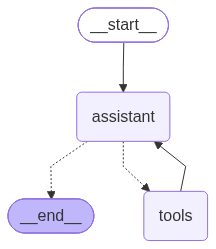

In [11]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

### Custom Tools Condition Logic

Below is the manual implementation of how LangGraph's pre-built `tools_condition` works under the hood. You can use this to understand the routing logic or customize your own agent behavior:

```python
def my_custom_tools_condition(state):
    # 1. Get the last message from the assistant
    last_message = state["messages"][-1]
    
    # 2. Check if the LLM wants to use a tool
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"  # Route to your ToolNode
        
    return "__end__"  # Stop the graph
```


In [12]:
messages = [HumanMessage(content="Add 3 and 4. Multiply the output by 2. Divide the output by 5")]
messages = react_graph.invoke({"messages": messages})

In [13]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4. Multiply the output by 2. Divide the output by 5
================================== Ai Message ==================================
Tool Calls:
  add (chatcmpl-tool-af02d8027dce7962)
 Call ID: chatcmpl-tool-af02d8027dce7962
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-91c07ba108eccb2c)
 Call ID: chatcmpl-tool-91c07ba108eccb2c
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================
Tool Calls:
  divide (chatcmpl-tool-b8cc96f28c2c91de)
 Call ID: chatcmpl-tool-b8cc96f28c2c91de
  Args:
    a: 14
    b: 5
================================= Tool Message =========

We don't retain memory from our past chat!

This is because state is `transient` to a single graph execution.

Of course, this limits our ability to have multi-turn conversations with interruptions.

We can use `persistence` to address this!

LangGraph can use a `checkpointer` to automatically __save the graph state__ after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the `MemorySaver`, an __in-memory key-value store__ for Graph state.

All we need to do is simply __compile the graph with a checkpointer__, and our graph has memory!

In [14]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

When we use memory, we need to specify a `thread_id`.

This `thread_id` will store our collection of graph states.

Here is a illusration:

* The checkpointer write the state at every step of the graph
* These checkpoints are saved in a thread
* We can access that thread in the future using the thread_id
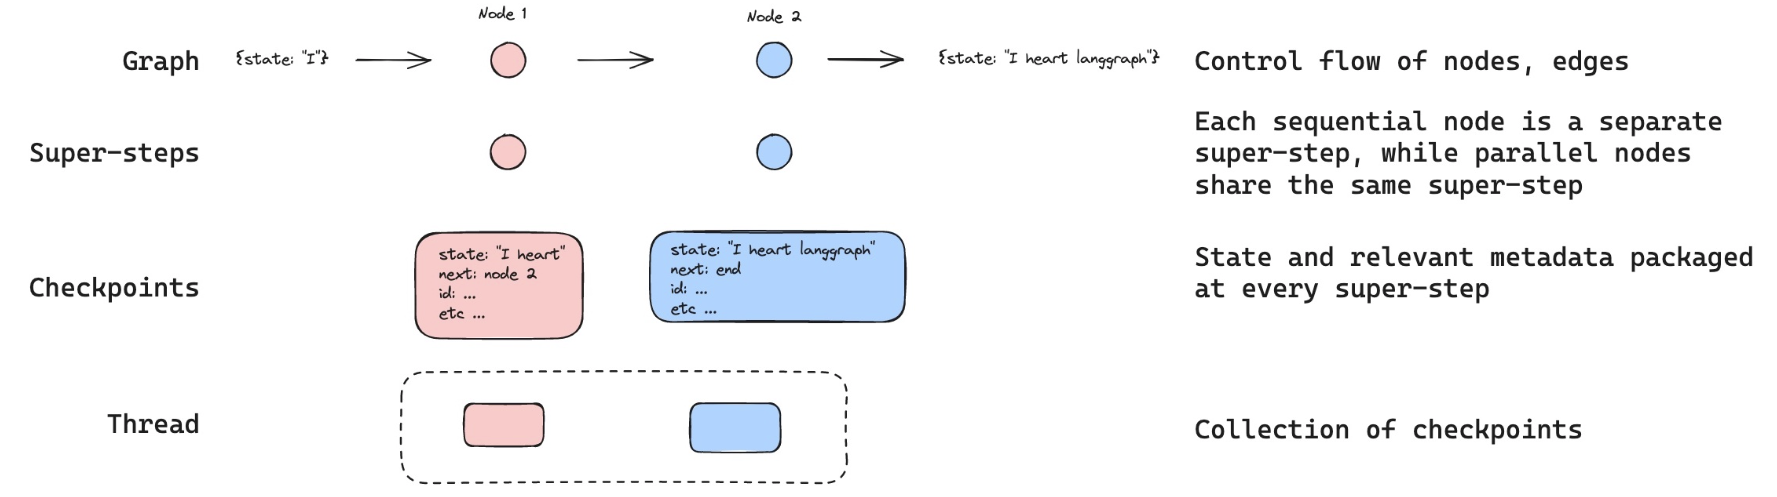


In [15]:
# Specify a thread
config = {"configurable": {"thread_id": "1"}}

# Specify an input
messages = [HumanMessage(content="Add 3 and 4.")]

# Run
messages = react_graph_memory.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (chatcmpl-tool-b3c23ef9d9a55faa)
 Call ID: chatcmpl-tool-b3c23ef9d9a55faa
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.


In [16]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (chatcmpl-tool-b3c23ef9d9a55faa)
 Call ID: chatcmpl-tool-b3c23ef9d9a55faa
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-b705715a93958d4b)
 Call ID: chatcmpl-tool-b705715a93958d4b
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================

The final res